# Discrete Laplace/Poisson Equation

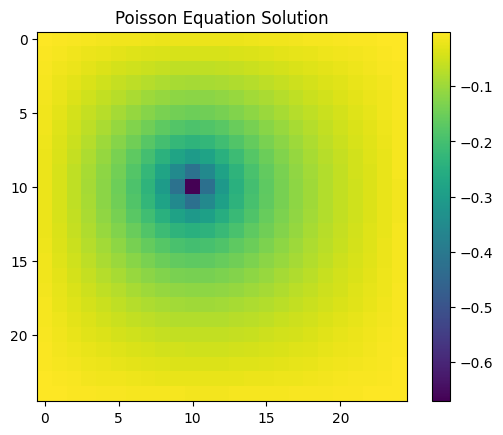

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix

def build_poisson_matrix(N):
    A = lil_matrix((N*N, N*N))
    for i in range(N):
        for j in range(N):
            idx = i * N + j
            A[idx, idx] = -4
            if i > 0:
                A[idx, (i-1)*N + j] = 1
            if i < N-1:
                A[idx, (i+1)*N + j] = 1
            if j > 0:
                A[idx, i*N + (j-1)] = 1
            if j < N-1:
                A[idx, i*N + (j+1)] = 1
    return A.tocsr()
def solve_poisson(N, b):
    A = build_poisson_matrix(N)
    x = np.linalg.solve(A.toarray(), b.flatten())
    return x.reshape((N, N))
N = 25
b = np.zeros((N, N))
b[10, 10] = 1  # Point source at the center
solution = solve_poisson(N, b)
plt.imshow(solution, cmap='viridis')
plt.colorbar()
plt.title('Poisson Equation Solution')
plt.show()

In [27]:
# build and solve poisson equation in matrix form Ax = b

L = 10
N  = 81
h = L / (N - 1)
x = np.linspace(0, L, N)
f_exact = np.cos(np.pi * x / L)
u = -(np.pi**2 / L**2) * f_exact

# boundary cond values
q0 = 0
gL = -1

e = np.ones(N)
laplacian = (np.diag(-2*e) + np.diag(e[:-1], 1) + np.diag(e[:-1], -1)) / h**2

b = f_exact.copy()

# impose neumann boundary condition at x=0
laplacian[0,:] = 0
laplacian[0, 0:2] = np.array([-3, 4, -1,] / (2*h))

# impose dirichlet boundary condition at x=L
laplacian[-1,:] = 0
laplacian[-1,-1] = 1


u_numeric = np.linalg.solve(laplacian, b)




TypeError: unsupported operand type(s) for /: 'list' and 'float'

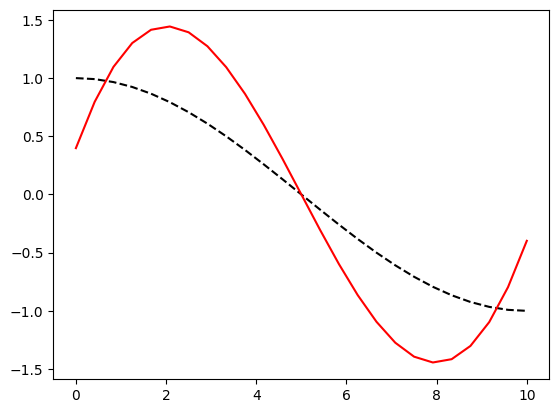

In [20]:
plt.plot(x, f_exact, label='Exact Solution', linestyle='dashed', color='black')
plt.plot(x, f_numeric, label='Numerical Solution', color='red')